In [2]:
import pickle as pkl
import random
import numpy as np
import os
import sys
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import calinski_harabasz_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx

import scanpy as sc
import anndata as ad

# GO analysis
from goatools.obo_parser import GODag
from goatools.associations import read_gaf
import gseapy as gp

import itertools
import tqdm
import math

NOTEBOOKS_DIR = Path.cwd().resolve()
if NOTEBOOKS_DIR.name != "notebooks":
    if (NOTEBOOKS_DIR / "notebooks").exists():
        NOTEBOOKS_DIR = NOTEBOOKS_DIR / "notebooks"
    elif NOTEBOOKS_DIR.parent.name == "notebooks":
        NOTEBOOKS_DIR = NOTEBOOKS_DIR.parent
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOKS_DIR))

from config import PATHS

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

/home/guoyu/SLformer_interpretation/.venv/lib/python3.10/site-packages/goatools/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
with open(PATHS["gene2id_map"], 'rb') as f: 
    gene2id_map = pkl.load(f)
    
with open(PATHS["cancer_list"]) as f:
    cancer_list = [line.rstrip('\n') for line in f]

id2gene_map = {i:g for g,i in gene2id_map.items()}
id2cancer_map = {i:cancer for i,cancer in enumerate(cancer_list)}
cancer2id_map = {cancer:i for i,cancer in enumerate(cancer_list)}

In [4]:
go_dag = GODag(PATHS["go_basic_obo"])
annotations = read_gaf(PATHS["goa_human_gaf"], go_dag=go_dag)

# Load ID mapping from UniProt to gene symbols
id_mapping = pd.read_csv(PATHS["idmapping_tsv"], sep='\t')
id_mapping = dict(zip(id_mapping['From'], id_mapping['To']))

# Map annotations to gene symbols
anno_mapped = {}
for k, v in annotations.items():
    if k in id_mapping:
        anno_mapped[id_mapping[k]] = v

/home/jienihu/sc/SLformer/data/GO/go-basic.obo: fmt(1.2) rel(2024-06-17) 45,494 Terms
HMS:0:00:13.420329 707,170 annotations READ: /home/jienihu/sc/SLformer/data/GO/goa_human.gaf 
36129 IDs in loaded association branch, BP


In [5]:
def find_shared_goterms(gene1, gene2, return_terms=False):
    """Find shared GO terms between two genes."""
    go_terms_gene1 = {go_id for go_id in anno_mapped.get(gene1, [])}
    go_terms_gene2 = {go_id for go_id in anno_mapped.get(gene2, [])}
    
    shared_go_terms = go_terms_gene1.intersection(go_terms_gene2)
    
    if return_terms:
        return len(shared_go_terms), list(shared_go_terms)
    else:
        return len(shared_go_terms)

def get_go_term_details(go_terms):
    """Get detailed information about GO terms."""
    details = []
    for term_id in go_terms:
        if term_id in go_dag:
            term = go_dag[term_id]
            details.append({
                'id': term_id,
                'name': term.name,
                'namespace': term.namespace,
                'depth': term.depth
            })
    return details

def cos_sim(A, B):
    """Calculate cosine similarity between two vectors."""
    dot_product = np.dot(A, B)
    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    return dot_product / (norm_A * norm_B)

In [6]:
res_dir = PATHS["all_sl_inference_dir"]
name = "mix_slformer_kg"

def get_emb(name, cancer=None):
    """Load and process embeddings from SLformer."""
    with open(os.path.join(res_dir, f"{name}_transformeremb.pkl"), 'rb') as f: 
        emb = pkl.load(f)
    
    if emb[0][0].ndim == 2:
        emb_gene1 = [emb[i][0] for i in range(5)]
        emb_gene2 = [emb[i][1] for i in range(5)]
    else:
        emb_gene1 = [emb[i][0][:,0,:] for i in range(5)]
        emb_gene2 = [emb[i][1][:,0,:] for i in range(5)]
    
    emb1_cat = np.concatenate(emb_gene1, axis=0)
    emb2_cat = np.concatenate(emb_gene2, axis=0)
    emb_total = np.concatenate([emb1_cat, emb2_cat], axis=0)

    df_all = [pd.read_csv(os.path.join(res_dir, f"pred_{name}_cv{cv}.csv")) for cv in range(1,6)]
    context_cat = pd.concat([df['cancer'] for df in df_all]).tolist()*2
    gene1_cat = pd.concat([df['primary_gene'] for df in df_all]).tolist()
    gene2_cat = pd.concat([df['partner_gene'] for df in df_all]).tolist()
    gene_total = gene1_cat+gene2_cat
    
    # Average embeddings for duplicate (gene, context) entries
    df = pd.DataFrame({
        'gene': gene_total,
        'context': context_cat,
        'embedding': list(emb_total)
    })

    avg_df = (
        df.groupby(['gene', 'context'])['embedding']
        .apply(lambda x: np.mean(np.stack(x), axis=0))
        .reset_index()
    )
    
    if cancer:
        avg_df = avg_df[avg_df['context'] == cancer]
        
    gene_unique = avg_df['gene'].tolist()
    context_unique = avg_df['context'].tolist()
    emb_unique = np.stack(avg_df['embedding'].tolist())
    
    return gene_unique, emb_unique, context_unique, avg_df

gene, emb, context, avg_df = get_emb(name)

In [7]:
def analyze_go_overlaps_comprehensive(gene, emb, context, n_pairs_per_cancer=1000):
    """Comprehensive analysis of GO term overlaps in gene embeddings."""
    results = {
        'same_gene_different_context': [],
        'different_genes_same_context': []
    }
    
    gene_context_df = pd.DataFrame({"gene": gene, "context": context, "embedding": list(emb)})
    
    # Same gene across different contexts
    for g in tqdm.tqdm(gene_context_df['gene'].unique(), desc="Analyzing same genes"):
        gene_df = gene_context_df[gene_context_df['gene'] == g]
        if len(gene_df) < 2:
            continue
            
        for i in range(len(gene_df)):
            for j in range(i+1, len(gene_df)):
                idx_i, idx_j = gene_df.index[i], gene_df.index[j]
                emb_sim = cos_sim(emb[idx_i], emb[idx_j])
                go_overlap = len(anno_mapped.get(g, []))
                
                results['same_gene_different_context'].append({
                    'gene': g,
                    'context1': gene_df.iloc[i]['context'],
                    'context2': gene_df.iloc[j]['context'],
                    'embedding_similarity': emb_sim,
                    'go_terms_count': go_overlap,
                    'pair_type': 'same_gene'
                })
    
    # Different genes within same context
    for cancer in tqdm.tqdm(gene_context_df['context'].unique(), desc="Analyzing different genes"):
        cancer_df = gene_context_df[gene_context_df['context'] == cancer]
        
        if len(cancer_df) > 50:
            sampled_pairs = []
            for _ in range(n_pairs_per_cancer):
                pair = cancer_df.sample(2, replace=False)
                sampled_pairs.append(pair)
        else:
            sampled_pairs = [cancer_df.iloc[[i,j]] for i in range(len(cancer_df)) 
                           for j in range(i+1, len(cancer_df))]
        
        for pair_df in sampled_pairs:
            if len(pair_df) != 2:
                continue
                
            gene1, gene2 = pair_df['gene'].iloc[0], pair_df['gene'].iloc[1]
            if gene1 == gene2:
                continue
                
            idx1, idx2 = pair_df.index[0], pair_df.index[1]
            emb_sim = cos_sim(emb[idx1], emb[idx2])
            go_overlap, shared_terms = find_shared_goterms(gene1, gene2, return_terms=True)
            
            results['different_genes_same_context'].append({
                'gene1': gene1,
                'gene2': gene2,
                'context': cancer,
                'embedding_similarity': emb_sim,
                'go_overlap_count': go_overlap,
                'shared_go_terms': shared_terms,
                'pair_type': 'different_genes'
            })
    
    df_same_gene = pd.DataFrame(results['same_gene_different_context'])
    df_diff_genes = pd.DataFrame(results['different_genes_same_context'])
    
    return df_same_gene, df_diff_genes

df_same_gene, df_diff_genes = analyze_go_overlaps_comprehensive(gene, emb, context, n_pairs_per_cancer=2000)

Analyzing different genes: 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]


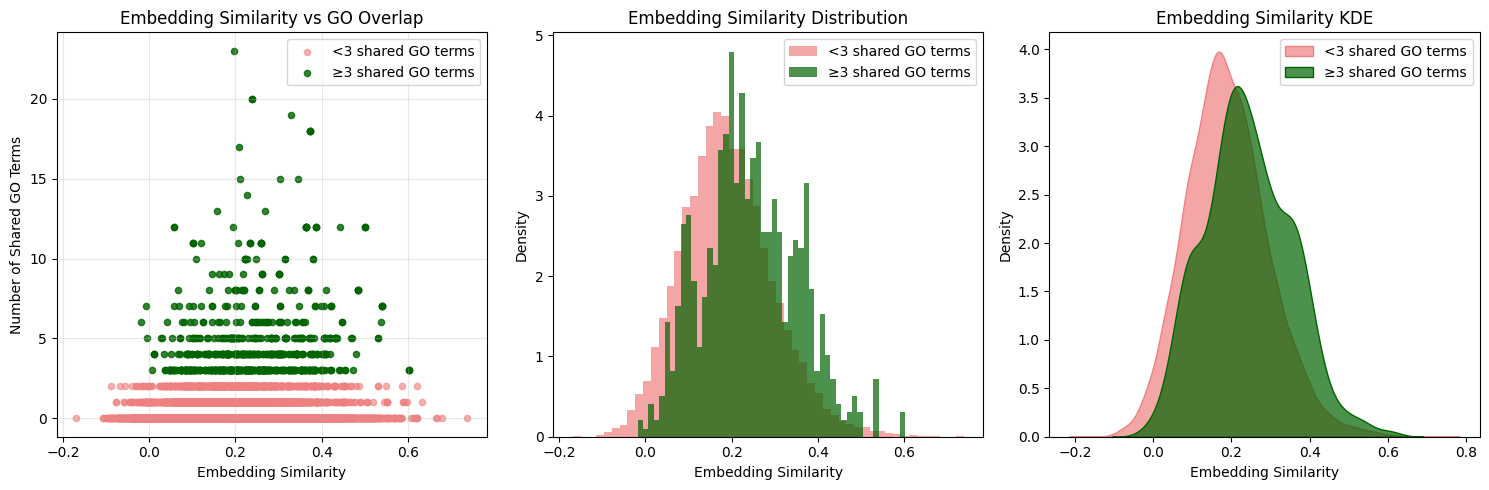

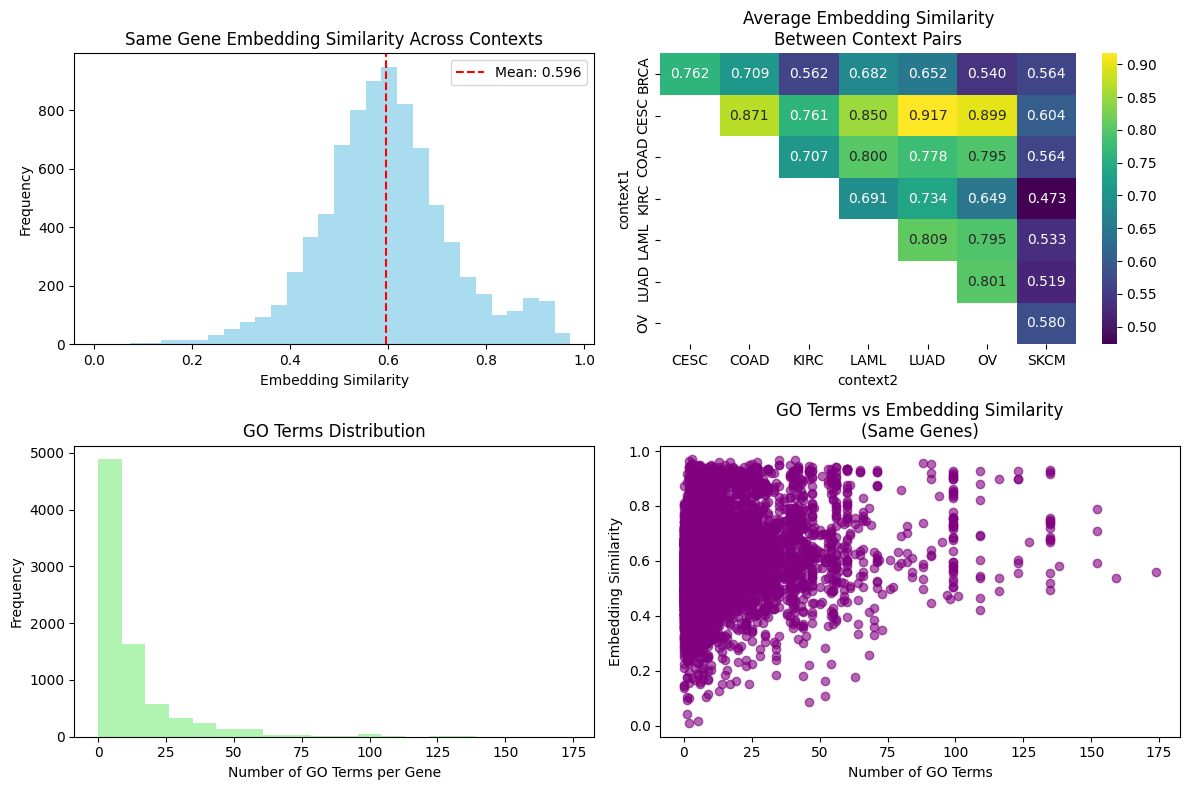

In [8]:
def plot_embedding_vs_go_similarity(df_diff_genes, go_threshold=3):
    """Plot embedding similarity vs GO overlap for different gene pairs."""
    plt.figure(figsize=(15, 5))
    
    high_go = df_diff_genes[df_diff_genes['go_overlap_count'] >= go_threshold]
    low_go = df_diff_genes[df_diff_genes['go_overlap_count'] < go_threshold]
    
    plt.subplot(1, 3, 1)
    plt.scatter(low_go['embedding_similarity'], low_go['go_overlap_count'], 
               alpha=0.6, color='lightcoral', s=20, label=f'<{go_threshold} shared GO terms')
    plt.scatter(high_go['embedding_similarity'], high_go['go_overlap_count'], 
               alpha=0.8, color='darkgreen', s=20, label=f'≥{go_threshold} shared GO terms')
    plt.xlabel('Embedding Similarity')
    plt.ylabel('Number of Shared GO Terms')
    plt.title('Embedding Similarity vs GO Overlap')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.hist(low_go['embedding_similarity'], bins=50, alpha=0.7, color='lightcoral', 
             label=f'<{go_threshold} shared GO terms', density=True)
    plt.hist(high_go['embedding_similarity'], bins=50, alpha=0.7, color='darkgreen', 
             label=f'≥{go_threshold} shared GO terms', density=True)
    plt.xlabel('Embedding Similarity')
    plt.ylabel('Density')
    plt.title('Embedding Similarity Distribution')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    sns.kdeplot(data=low_go, x='embedding_similarity', fill=True, alpha=0.7, 
                color='lightcoral', label=f'<{go_threshold} shared GO terms')
    sns.kdeplot(data=high_go, x='embedding_similarity', fill=True, alpha=0.7, 
                color='darkgreen', label=f'≥{go_threshold} shared GO terms')
    plt.xlabel('Embedding Similarity')
    plt.ylabel('Density')
    plt.title('Embedding Similarity KDE')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def plot_same_gene_context_similarity(df_same_gene):
    """Plot how same genes vary across different contexts."""
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 2, 1)
    plt.hist(df_same_gene['embedding_similarity'], bins=30, alpha=0.7, color='skyblue')
    plt.xlabel('Embedding Similarity')
    plt.ylabel('Frequency')
    plt.title('Same Gene Embedding Similarity Across Contexts')
    plt.axvline(df_same_gene['embedding_similarity'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df_same_gene["embedding_similarity"].mean():.3f}')
    plt.legend()
    
    plt.subplot(2, 2, 2)
    context_similarity = df_same_gene.groupby(['context1', 'context2'])['embedding_similarity'].mean().reset_index()
    pivot_table = context_similarity.pivot(index='context1', columns='context2', values='embedding_similarity')
    sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.3f')
    plt.title('Average Embedding Similarity\nBetween Context Pairs')
    
    plt.subplot(2, 2, 3)
    plt.hist(df_same_gene['go_terms_count'], bins=20, alpha=0.7, color='lightgreen')
    plt.xlabel('Number of GO Terms per Gene')
    plt.ylabel('Frequency')
    plt.title('GO Terms Distribution')
    
    plt.subplot(2, 2, 4)
    plt.scatter(df_same_gene['go_terms_count'], df_same_gene['embedding_similarity'], 
               alpha=0.6, color='purple')
    plt.xlabel('Number of GO Terms')
    plt.ylabel('Embedding Similarity')
    plt.title('GO Terms vs Embedding Similarity\n(Same Genes)')
    
    plt.tight_layout()
    plt.show()
    
plot_embedding_vs_go_similarity(df_diff_genes, go_threshold=3)
plot_same_gene_context_similarity(df_same_gene)

In [9]:
def analyze_high_similarity_pairs(df_diff_genes, embedding_threshold=0.5, go_threshold=5):
    """Analyze gene pairs with high embedding similarity and GO overlap."""
    high_sim_pairs = df_diff_genes[
        (df_diff_genes['embedding_similarity'] >= embedding_threshold) & 
        (df_diff_genes['go_overlap_count'] >= go_threshold)
    ].copy()
    
    if len(high_sim_pairs) == 0:
        high_sim_pairs = df_diff_genes[
            (df_diff_genes['embedding_similarity'] >= 0.7) & 
            (df_diff_genes['go_overlap_count'] >= 3)
        ].copy()
    
    high_sim_pairs = high_sim_pairs.sort_values('embedding_similarity', ascending=False)

    detailed_pairs = []
    for idx, row in high_sim_pairs.head(20).iterrows():
        shared_terms = row['shared_go_terms']
        term_details = get_go_term_details(shared_terms)
        
        detailed_pairs.append({
            'gene1': row['gene1'],
            'gene2': row['gene2'],
            'context': row['context'],
            'embedding_similarity': row['embedding_similarity'],
            'go_overlap_count': row['go_overlap_count'],
            'shared_go_terms': shared_terms,
            'go_term_details': term_details
        })
    
    return pd.DataFrame(detailed_pairs), high_sim_pairs

detailed_df, high_sim_all = analyze_high_similarity_pairs(df_diff_genes, embedding_threshold=0.5, go_threshold=3)

In [10]:
def preprocess_data_for_gmm(X):
    """Preprocess data for GMM clustering to ensure numerical stability."""
    X = X.astype(np.float64)

    if np.any(np.isnan(X)):
        X = np.nan_to_num(X, nan=0.0)
    
    if np.any(np.isinf(X)):
        X = np.nan_to_num(X, posinf=1.0, neginf=-1.0)
   
    feature_var = np.var(X, axis=0)
    constant_features = feature_var < 1e-12
    if np.any(constant_features):
        X[:, constant_features] += np.random.normal(0, 1e-6, (X.shape[0], np.sum(constant_features)))
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, scaler

def build_gene_adata(gene, emb, context, cancer_type):
    """Create AnnData object for gene embeddings from a specific cancer context."""
    gene = np.array(gene)
    emb = np.array(emb)
    context = np.array(context)

    mask = context == cancer_type
    emb_cancer = emb[mask]
    gene_cancer = gene[mask]

    adata = ad.AnnData(X=emb_cancer)
    adata.obs['gene'] = gene_cancer
    adata.obs['context'] = cancer_type

    return adata

def run_louvain_clustering(adata, resolution=2.0):
    """Run Louvain clustering on the gene-level embeddings."""
    sc.pp.neighbors(adata, n_neighbors=15, use_rep="X")
    sc.tl.leiden(adata, resolution=resolution, key_added='gene_cluster')
    return adata

def improved_clustering_analysis(gene, emb, context, cancer_name):
    """Multi-resolution clustering with stability analysis."""
    adata = build_gene_adata(gene, emb, context, cancer_name)
    adata.X, _ = preprocess_data_for_gmm(adata.X)
    
    resolutions = np.logspace(np.log10(0.5), np.log10(5), 20)
    resolutions = np.round(resolutions, 2)
    stability_scores = []
    
    for res in resolutions:
        adata_temp = adata.copy()
        adata_temp = run_louvain_clustering(adata_temp, resolution=res)
        
        try:
            cluster_labels = adata_temp.obs['gene_cluster'].astype('category').cat.codes
            ch_score = calinski_harabasz_score(adata_temp.X, cluster_labels)
            stability_scores.append(ch_score)
        except:
            stability_scores.append(0)
    
    optimal_res = resolutions[np.argmax(stability_scores)]
    return run_louvain_clustering(adata, resolution=optimal_res)

def get_metagenes(adata, min_genes=5):
    """Retrieve gene clusters with >= min_genes genes."""
    clusters = adata.obs['gene_cluster'].unique()
    metagenes = {}
    for cluster in clusters:
        genes = adata.obs.loc[adata.obs['gene_cluster'] == cluster, 'gene'].tolist()
        if len(genes) >= min_genes:
            metagenes[str(cluster)] = genes
    return metagenes

cancer_name = "BRCA"
adata = improved_clustering_analysis(gene, emb, context, cancer_name)
metagenes = get_metagenes(adata, min_genes=5)
emb_dict = {g: vec for g, vec in zip(adata.obs['gene'], adata.X)}

/home/guoyu/SLformer_interpretation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_486828/2008209294.py:40: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added='gene_cluster')


In [11]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

def determine_optimal_gmm_components(X, max_components=20, cv_type='diag'):
    """Determine optimal number of components for GMM using multiple criteria."""
    n_samples, n_features = X.shape
    max_components = min(max_components, n_samples // 10, n_features // 2)
    
    if max_components < 2:
        max_components = 2
    
    n_components_range = range(2, max_components + 1)
    
    aic_scores = []
    bic_scores = []
    silhouette_scores = []
    log_likelihoods = []
    
    for n_components in n_components_range:
        try:
            gmm = GaussianMixture(
                n_components=n_components, 
                covariance_type=cv_type,
                random_state=SEED,
                max_iter=300,
                reg_covar=1e-5,
                init_params='k-means++',
                tol=1e-4
            )
            gmm.fit(X)
            
            labels = gmm.predict(X)
            
            aic_scores.append(gmm.aic(X))
            bic_scores.append(gmm.bic(X))
            log_likelihoods.append(gmm.score(X))
            
            if len(set(labels)) > 1:
                sil_score = silhouette_score(X, labels)
                silhouette_scores.append(sil_score)
            else:
                silhouette_scores.append(-1)
                
        except:
            aic_scores.append(np.inf)
            bic_scores.append(np.inf)
            log_likelihoods.append(-np.inf)
            silhouette_scores.append(-1)
    
    optimal_aic = n_components_range[np.argmin(aic_scores)]
    optimal_bic = n_components_range[np.argmin(bic_scores)]
    optimal_silhouette = n_components_range[np.argmax(silhouette_scores)]
    
    results = {
        'n_components_range': list(n_components_range),
        'aic_scores': aic_scores,
        'bic_scores': bic_scores,
        'silhouette_scores': silhouette_scores,
        'log_likelihoods': log_likelihoods,
        'optimal_aic': optimal_aic,
        'optimal_bic': optimal_bic,
        'optimal_silhouette': optimal_silhouette
    }
    
    return results

def run_gmm_clustering(adata, n_components=None, covariance_type='diag'):
    """Run Gaussian Mixture Model clustering on gene embeddings."""
    X = adata.X.copy()
    X_scaled, scaler = preprocess_data_for_gmm(X)
    
    if n_components is None:
        model_selection = determine_optimal_gmm_components(X_scaled, max_components=12, cv_type=covariance_type)
        n_components = model_selection['optimal_bic']
    
    covariance_types_to_try = [covariance_type, 'diag', 'spherical', 'tied']
    
    gmm = None
    for cov_type in covariance_types_to_try:
        try:
            gmm = GaussianMixture(
                n_components=n_components,
                covariance_type=cov_type,
                random_state=SEED,
                max_iter=500,
                reg_covar=1e-4,
                init_params='k-means++',
                tol=1e-3,
                warm_start=False
            )
            
            gmm.fit(X_scaled)
            covariance_type = cov_type
            break
            
        except:
            if cov_type == covariance_types_to_try[-1]:
                raise Exception("All covariance types failed")
            continue
    
    cluster_labels = gmm.predict(X_scaled)
    cluster_probs = gmm.predict_proba(X_scaled)
    
    adata.obs['gmm_cluster'] = cluster_labels.astype(str)
    adata.obs['gmm_uncertainty'] = 1 - np.max(cluster_probs, axis=1)
    
    adata.uns['gmm_model'] = {
        'n_components': n_components,
        'covariance_type': covariance_type,
        'aic': gmm.aic(X_scaled),
        'bic': gmm.bic(X_scaled),
        'log_likelihood': gmm.score(X_scaled),
        'converged': gmm.converged_,
        'n_iter': gmm.n_iter_,
        'scaler': scaler
    }
    
    return adata, gmm

def compare_clustering_methods(adata_leiden, adata_gmm):
    """Compare Leiden and GMM clustering results."""
    leiden_labels = adata_leiden.obs['gene_cluster'].astype('category').cat.codes
    gmm_labels = adata_gmm.obs['gmm_cluster'].astype('category').cat.codes
    
    ari_score = adjusted_rand_score(leiden_labels, gmm_labels)
    
    X = adata_leiden.X
    leiden_silhouette = silhouette_score(X, leiden_labels) if len(set(leiden_labels)) > 1 else -1
    gmm_silhouette = silhouette_score(X, gmm_labels) if len(set(gmm_labels)) > 1 else -1
    
    leiden_cluster_sizes = pd.Series(leiden_labels).value_counts().sort_index()
    gmm_cluster_sizes = pd.Series(gmm_labels).value_counts().sort_index()
    
    return {
        'adjusted_rand_index': ari_score,
        'leiden_silhouette': leiden_silhouette,
        'gmm_silhouette': gmm_silhouette,
        'leiden_n_clusters': len(set(leiden_labels)),
        'gmm_n_clusters': len(set(gmm_labels)),
        'leiden_cluster_sizes': leiden_cluster_sizes,
        'gmm_cluster_sizes': gmm_cluster_sizes
    }

def plot_clustering_comparison(adata_leiden, adata_gmm, comparison_results, method='pca'):
    """Visualize comparison between Leiden and GMM clustering."""
    from sklearn.manifold import TSNE

    plt.figure(figsize=(15, 10))

    X = adata_leiden.X
    if X.shape[1] > 2:
        if method == 'tsne':
            tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
            X_2d = tsne.fit_transform(X)
            var_explained = [None, None]
        else:
            pca = PCA(n_components=2, random_state=SEED)
            X_2d = pca.fit_transform(X)
            var_explained = pca.explained_variance_ratio_
    else:
        X_2d = X
        var_explained = [1.0, 1.0]

    # Plot 1: Leiden clustering
    plt.subplot(2, 3, 1)
    leiden_labels = adata_leiden.obs['gene_cluster'].astype('category').cat.codes
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=leiden_labels, cmap='tab20', alpha=0.7, s=30)
    if var_explained[0] is not None:
        plt.xlabel(f'PC1 ({var_explained[0]:.1%} var)')
        plt.ylabel(f'PC2 ({var_explained[1]:.1%} var)')
    else:
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
    plt.title(f'Leiden Clustering\n({len(set(leiden_labels))} clusters)')
    plt.colorbar(scatter)

    # Plot 2: GMM clustering
    plt.subplot(2, 3, 2)
    gmm_labels = adata_gmm.obs['gmm_cluster'].astype('category').cat.codes
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=gmm_labels, cmap='tab20', alpha=0.7, s=30)
    if var_explained[0] is not None:
        plt.xlabel(f'PC1 ({var_explained[0]:.1%} var)')
        plt.ylabel(f'PC2 ({var_explained[1]:.1%} var)')
    else:
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
    plt.title(f'GMM Clustering\n({len(set(gmm_labels))} clusters)')
    plt.colorbar(scatter)

    # Plot 3: Uncertainty map for GMM
    plt.subplot(2, 3, 3)
    uncertainty = adata_gmm.obs['gmm_uncertainty']
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=uncertainty, cmap='Reds', alpha=0.7, s=30)
    if var_explained[0] is not None:
        plt.xlabel(f'PC1 ({var_explained[0]:.1%} var)')
        plt.ylabel(f'PC2 ({var_explained[1]:.1%} var)')
    else:
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
    plt.title('GMM Clustering Uncertainty')
    plt.colorbar(scatter, label='Uncertainty')
    
    # Plot 4: Cluster size comparison
    plt.subplot(2, 3, 4)
    leiden_sizes = comparison_results['leiden_cluster_sizes']
    gmm_sizes = comparison_results['gmm_cluster_sizes']
    
    x = np.arange(max(len(leiden_sizes), len(gmm_sizes)))
    leiden_vals = [leiden_sizes.get(i, 0) for i in x]
    gmm_vals = [gmm_sizes.get(i, 0) for i in x]
    
    width = 0.35
    plt.bar(x - width/2, leiden_vals, width, label='Leiden', alpha=0.7)
    plt.bar(x + width/2, gmm_vals, width, label='GMM', alpha=0.7)
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of Genes')
    plt.title('Cluster Size Comparison')
    plt.legend()
    
    # Plot 5: Metrics comparison
    plt.subplot(2, 3, 5)
    methods = ['Leiden', 'GMM']
    silhouette_scores = [comparison_results['leiden_silhouette'], comparison_results['gmm_silhouette']]
    n_clusters = [comparison_results['leiden_n_clusters'], comparison_results['gmm_n_clusters']]
    
    x = np.arange(len(methods))
    width = 0.35
    
    ax1 = plt.gca()
    ax1.bar(x - width/2, silhouette_scores, width, label='Silhouette Score', alpha=0.7, color='skyblue')
    ax1.set_xlabel('Method')
    ax1.set_ylabel('Silhouette Score', color='blue')
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods)
    ax1.tick_params(axis='y', labelcolor='blue')
    
    ax2 = ax1.twinx()
    ax2.bar(x + width/2, n_clusters, width, label='Number of Clusters', alpha=0.7, color='lightcoral')
    ax2.set_ylabel('Number of Clusters', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    plt.title('Clustering Quality Metrics')
    
    # Plot 6: Agreement visualization
    plt.subplot(2, 3, 6)
    ari_score = comparison_results['adjusted_rand_index']
    plt.bar(['ARI'], [ari_score], color='green', alpha=0.7)
    plt.ylabel('Adjusted Rand Index')
    plt.title(f'Method Agreement\n(ARI: {ari_score:.3f})')
    plt.ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

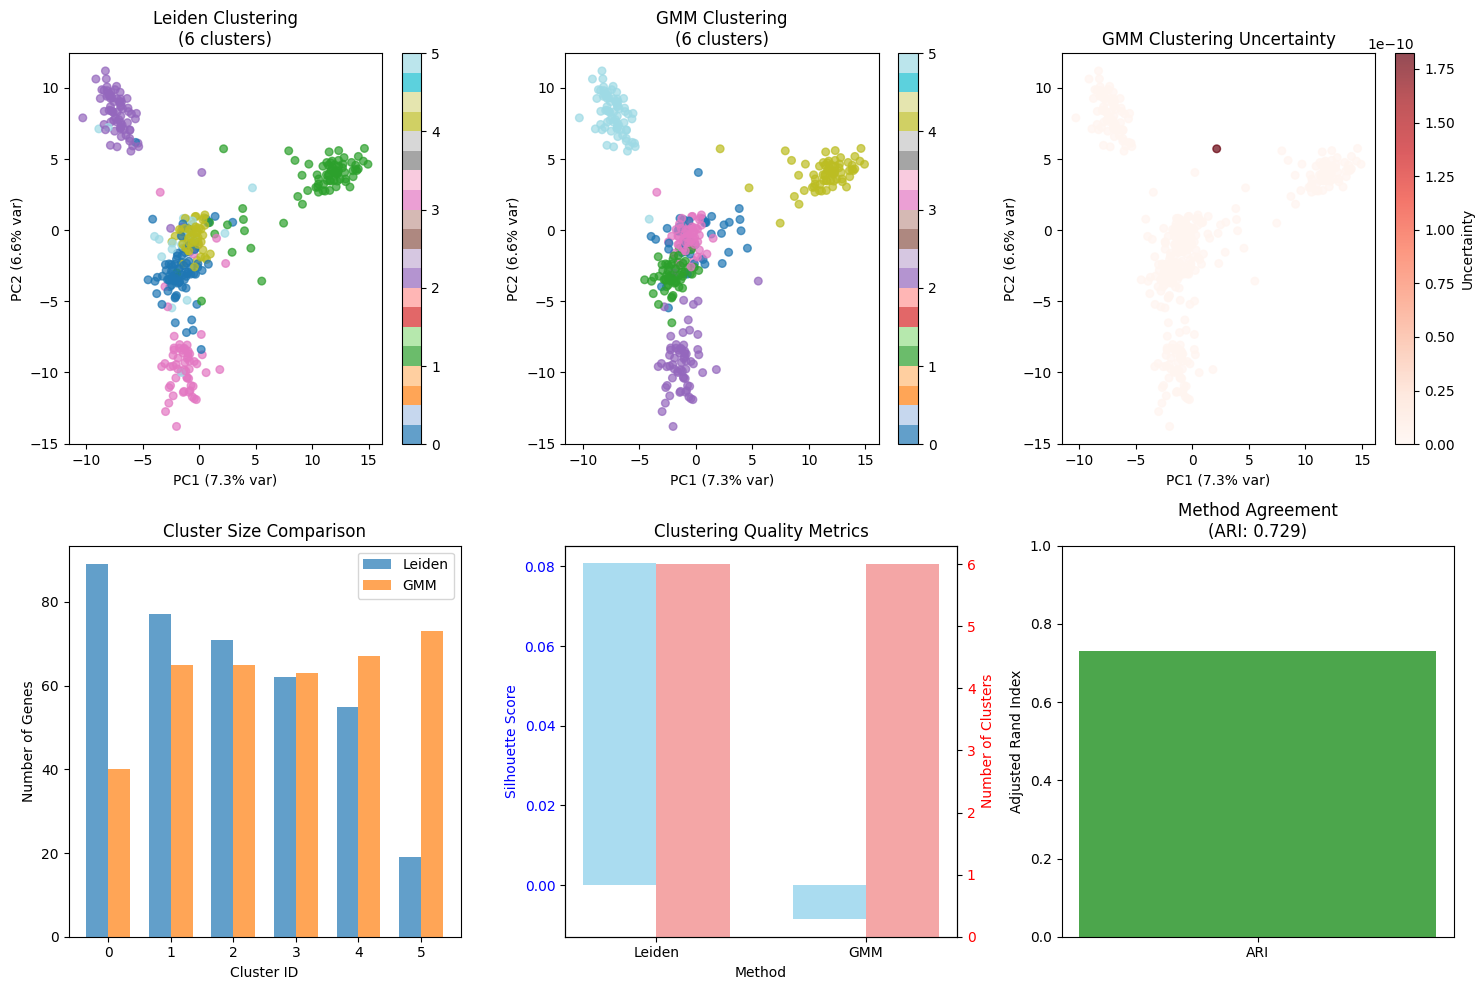

In [12]:
adata_gmm = adata.copy()
adata_gmm, gmm_model = run_gmm_clustering(adata_gmm, n_components=None, covariance_type='diag')

def get_gmm_metagenes(adata, min_genes=5):
    """Retrieve GMM gene clusters with >= min_genes genes."""
    clusters = adata.obs['gmm_cluster'].unique()
    metagenes = {}
    for cluster in clusters:
        genes = adata.obs.loc[adata.obs['gmm_cluster'] == cluster, 'gene'].tolist()
        if len(genes) >= min_genes:
            metagenes[str(cluster)] = genes
    return metagenes

gmm_metagenes = get_gmm_metagenes(adata_gmm, min_genes=5)
comparison_results = compare_clustering_methods(adata, adata_gmm)
plot_clustering_comparison(adata, adata_gmm, comparison_results, method='PCA')

In [13]:
def calculate_avg_go_terms(df_same_gene, df_diff_genes, cancer_type, top_n=5):
    """Calculate average number of shared GO terms for top N gene pairs in each cluster."""
    df_same_gene_cancer = df_same_gene[df_same_gene['context1'] == cancer_type]
    df_diff_genes_cancer = df_diff_genes[df_diff_genes['context'] == cancer_type]
    
    top_same_gene = df_same_gene_cancer.sort_values('embedding_similarity', ascending=False).head(top_n)
    top_diff_genes = df_diff_genes_cancer.sort_values('embedding_similarity', ascending=False).head(top_n)
    
    avg_go_terms_same = top_same_gene['go_terms_count'].mean()
    avg_go_terms_diff = top_diff_genes['go_overlap_count'].mean()
    
    return avg_go_terms_same, avg_go_terms_diff

cancer_type = "BRCA"
avg_go_terms_brca = calculate_avg_go_terms(df_same_gene, df_diff_genes, cancer_type, top_n=100)

In [14]:
random.seed(42)
gene_pool = set()
for gene_list in metagenes.values():
    gene_pool.update(gene_list)
gene_pool = list(gene_pool)
gene_pool = [g for g in gene_pool if g in anno_mapped]

def analyze_go_similarity_in_metagenes(metagenes, min_shared_threshold=3):
    """
    For each gene cluster, compute number of shared GO terms per gene pair,
    and count how many exceed a threshold (e.g., ≥3 shared GO terms).
    """
    all_results = []
    summary = []

    for cluster_id, genes in metagenes.items():
        gene_pairs = list(itertools.combinations(genes, 2))
        cluster_data = []

        for g1, g2 in gene_pairs:
            shared_go_count, shared_go_list = find_shared_goterms(g1, g2, return_terms=True)
            cluster_data.append({
                'cluster': cluster_id,
                'gene1': g1,
                'gene2': g2,
                'n_shared': shared_go_count,
                'shared_terms': shared_go_list
            })

        df_cluster = pd.DataFrame(cluster_data)
        high_shared_count = (df_cluster['n_shared'] >= min_shared_threshold).sum()
        avg_shared = df_cluster['n_shared'].mean()
        # background
        sampled_pairs = random.sample(list(itertools.combinations(gene_pool, 2)), len(gene_pairs))
        backgound_avg_shared = np.mean([find_shared_goterms(g1, g2) for g1, g2 in sampled_pairs])

        summary.append({
            'cluster': cluster_id,
            'num_genes': len(genes),
            'num_pairs': len(gene_pairs),
            'high_shared_pairs': high_shared_count,
            'avg_shared_terms': avg_shared,
            'background_avg_shared_terms': backgound_avg_shared
        })

        all_results.append(df_cluster)

    df_all_pairs = pd.concat(all_results, ignore_index=True)
    df_summary = pd.DataFrame(summary)

    return df_all_pairs, df_summary

def compute_background_shared_go(metagenes, anno_mapped, num_samples=5000):
    """Sample random gene pairs from the full gene set and compute shared GO terms."""
    random.seed(42)
    gene_pool = set()
    for gene_list in metagenes.values():
        gene_pool.update(gene_list)
    gene_pool = list(gene_pool)
    gene_pool = [g for g in gene_pool if g in anno_mapped]
    if len(gene_pool) < 2:
        return pd.DataFrame()
    
    max_possible_pairs = len(list(itertools.combinations(gene_pool, 2)))
    actual_samples = min(num_samples, max_possible_pairs)
    sampled_pairs = random.sample(list(itertools.combinations(gene_pool, 2)), actual_samples)

    results = []
    for g1, g2 in sampled_pairs:
        shared_go_count, shared_go_list = find_shared_goterms(g1, g2, return_terms=True)
        results.append({
            'gene1': g1,
            'gene2': g2,
            'n_shared': shared_go_count,
            'shared_terms': shared_go_list
        })

    return pd.DataFrame(results)

In [15]:
leiden_metagenes = get_metagenes(adata, min_genes=5)

if leiden_metagenes:
    leiden_go_all, leiden_go_summary = analyze_go_similarity_in_metagenes(
        leiden_metagenes, min_shared_threshold=3
    )
    leiden_overall_avg = leiden_go_all['n_shared'].mean() if not leiden_go_all.empty else 0
else:
    leiden_overall_avg = 0

if gmm_metagenes:
    gmm_go_all, gmm_go_summary = analyze_go_similarity_in_metagenes(
        gmm_metagenes, min_shared_threshold=3
    )
    gmm_overall_avg = gmm_go_all['n_shared'].mean() if not gmm_go_all.empty else 0
else:
    gmm_overall_avg = 0

all_metagenes = {**leiden_metagenes, **gmm_metagenes} if leiden_metagenes and gmm_metagenes else (leiden_metagenes or gmm_metagenes)

if all_metagenes:
    df_background = compute_background_shared_go(metagenes, anno_mapped, num_samples=10000)
    background_avg = df_background['n_shared'].mean() if not df_background.empty else 0
else:
    background_avg = 0

leiden_beats_bg = leiden_overall_avg > background_avg
gmm_beats_bg = gmm_overall_avg > background_avg

In [16]:
print("Summary of GO term sharing per cluster:")
gmm_go_summary_sorted = gmm_go_summary.sort_values(by='avg_shared_terms', ascending=False)
print(gmm_go_summary_sorted)

Summary of GO term sharing per cluster:
  cluster  num_genes  num_pairs  high_shared_pairs  avg_shared_terms  \
2       0         40        780                 43          0.525641   
1       1         65       2080                 49          0.265865   
3       4         67       2211                 32          0.195387   
0       3         63       1953                 18          0.165387   
5       2         65       2080                 23          0.149038   
4       5         73       2628                 28          0.143836   

   background_avg_shared_terms  
2                     0.203846  
1                     0.192308  
3                     0.201266  
0                     0.197645  
5                     0.209615  
4                     0.210426  


In [17]:
gmm_go_summary_sorted.to_csv('output/cluster_part/GMM_GO_cluster_summary.csv', index=False)

In [18]:
gene1 = gmm_go_all[gmm_go_all['cluster'] == '0']['gene1']
gene2 = gmm_go_all[gmm_go_all['cluster'] == '0']['gene2']
import json
pairs = list(zip(gene1.to_list(), gene2.to_list()))
json.dump(pairs, open('output/cluster_part/GMM_cluster0_pairs.json', 'w'))

In [19]:
from scipy.stats import ttest_ind, mannwhitneyu

def test_within_cluster_significance_detailed(cluster_id="0", threshold=3, alpha=0.05):
    """Test if gene pairs with high GO term counts are significantly different from background within a cluster."""
    detailed_df = gmm_go_all
    cluster_data = detailed_df[detailed_df['cluster'] == cluster_id].copy()
    
    go_term_col = 'n_shared'
    
    high_go_pairs = cluster_data[cluster_data[go_term_col] > threshold]
    background_pairs = compute_background_shared_go(all_metagenes, anno_mapped, num_samples=10000)
    
    cluster_values = cluster_data[go_term_col].values
    background_values = background_pairs[go_term_col].values

    t_stat, t_pvalue = ttest_ind(cluster_values, background_values, equal_var=False)
    u_stat, u_pvalue = mannwhitneyu(cluster_values, background_values, alternative='two-sided')
    
    return {
        't_test': {'statistic': t_stat, 'p_value': t_pvalue, 'significant': t_pvalue < alpha},
        'mann_whitney': {'statistic': u_stat, 'p_value': u_pvalue, 'significant': u_pvalue < alpha},
        'cluster_mean': cluster_values.mean(),
        'background_mean': background_values.mean(),
        'high_go_count': len(high_go_pairs),
        'background_count': len(background_pairs),
        'threshold_used': threshold,
        'effect_size': (cluster_values.mean() - background_values.mean()) / background_values.std() if background_values.std() > 0 else 0
    }

all_cluster_analyses = {}
for cluster_id in range(6):
    cluster_id_str = str(cluster_id)
    if cluster_id_str in gmm_metagenes:
        results = test_within_cluster_significance_detailed(cluster_id=cluster_id_str, threshold=3)
        all_cluster_analyses[cluster_id_str] = results
all_cluster_analyses

{'0': {'t_test': {'statistic': np.float64(8.083554630132202),
   'p_value': np.float64(2.231678173199324e-15),
   'significant': np.True_},
  'mann_whitney': {'statistic': np.float64(4526993.0),
   'p_value': np.float64(1.2922972585083812e-33),
   'significant': np.True_},
  'cluster_mean': np.float64(0.5256410256410257),
  'background_mean': np.float64(0.212),
  'high_go_count': 23,
  'background_count': 10000,
  'threshold_used': 3,
  'effect_size': np.float64(0.47726917566647126)},
 '1': {'t_test': {'statistic': np.float64(3.0232494577279794),
   'p_value': np.float64(0.002523672855427672),
   'significant': np.True_},
  'mann_whitney': {'statistic': np.float64(10646188.5),
   'p_value': np.float64(0.005036618527230595),
   'significant': np.True_},
  'cluster_mean': np.float64(0.2658653846153846),
  'background_mean': np.float64(0.212),
  'high_go_count': 24,
  'background_count': 10000,
  'threshold_used': 3,
  'effect_size': np.float64(0.08196723518487078)},
 '2': {'t_test': {'st

In [20]:
df_database = pd.DataFrame([
    ['GO_Biological_Process_2021', 6036],
    ['GO_Molecular_Function_2021', 1274],
    ['Reactome_2022', 1818],
    ['KEGG_2021_Human', 332]
], columns=['dataset', 'term'])
databases = ['Reactome_2022']
m = df_database[df_database['dataset'].isin(databases)]['term'].sum()
p_thresh = 0.05 / m

In [21]:
selected_cluster = '0'  
gene_list = gmm_metagenes[selected_cluster]
enr_result = gp.enrichr(
    gene_list=gene_list,
    gene_sets=databases,
    organism='Human',
    outdir=f'output/cluster_part/enr_results/{cancer_name}/GMM_custer{selected_cluster}',
    cutoff=0.05,
)

result_df = enr_result.results
filtered_df = result_df[result_df['P-value'] < p_thresh]
filtered_df[['Term', 'P-value', 'Adjusted P-value', 'Genes']].head()

,Term,P-value,Adjusted P-value,Genes
0,Generic Transcription Pathway R-HSA-212436,3.479317e-08,0.000012,RB1;NOTCH2;PARP1;MAML2;LMO2;PTEN;BRCA1;GATA3;N...
1,Gene Expression (Transcription) R-HSA-74160,5.272413e-08,0.000012,RB1;NOTCH2;PARP1;MAML2;LMO2;PTEN;BRCA1;GATA3;N...
2,RNA Polymerase II Transcription R-HSA-73857,1.175574e-07,0.000018,RB1;NOTCH2;PARP1;MAML2;LMO2;PTEN;BRCA1;GATA3;N...
3,Disease R-HSA-1643685,5.596836e-07,0.000063,RB1;NOTCH2;PARP1;MAML2;RPL22;PTEN;PIK3R1;BRCA1...
4,Impaired BRCA2 Binding To PALB2 R-HSA-9709603,1.456833e-05,0.001248,BRIP1;BRCA1;BRCA2
